# Deployment 4: noise dropouts — the self-RFI floor switching off, and its rotation dependence

Follow-up to `radiated_selfRFI_lines.ipynb` / `explore_24h_july19_20.ipynb`, prompted by the reviewer comment: *"the manuscript identifies self-generated RFI as the dominant systematic in field measurements but provides only limited characterization of its current level or mitigation strategy."*

arp's `EIGSEP_data_explore_v004_noise_dropout.ipynb` catalogued 19 "noise dropout" events by eye and suspected they were **our own RFI quieting down** rather than anything in the receiver, partly because the floor looked rotation-dependent. This notebook tests that hypothesis against the housekeeping telemetry (motors, IMUs, temperature control, RF switch, VNA schedule) and the full 5-day correlator record. Findings:

- The dropouts are square, ~4-min, 1–3 dB drops of a **broadband (~30–160 MHz) noise floor**, visible in the suspended bowtie and ants 3/4 but **absent in ant 0** — a near-field, on-site source.
- The calibration comb is constant through the dropouts (±0.1 dB) → not the transmit chain, and not receiver gain. The narrowband self-RFI lines (244.14, 152.59 MHz) do **not** switch with the floor → the duty-cycled device radiates specifically the broadband floor; the line radiators stay on.
- 91 detected events on Jul 17–20 (~20/day, day **and** night; median duration 233 s; quasi-period ~25–70 min; the floor is off ~11% of antenna-state time). The rig is **stationary during every event** (IMUs frozen, motor server idle) → the dropouts are a **duty cycle of an on-site device**, not a rotation effect. The tight ~240 s duration suggests a software-timed process.
- The rotation dependence is real, but it is a property of the *steady* emission: during the Jul 19 beam-mapping raster the **stationary** bowtie's floor modulates by up to ~1.5 dB synchronously with platform pitch, and the 244 MHz line drops ~3 dB and oscillates, snapping back when the platform parks. Received power at a fixed antenna tracking *our* platform orientation is only possible for near-field, on-structure sources — this pins both the floor and the line to the rotating platform.
- The dropout depth is an **in-situ measurement of the self-RFI floor level**: on the bowtie it is typically ~10% of the total measured power across 40–150 MHz, peaking at ~40% at specific frequencies, and it is present ~89% of the time.

Data: `../../../data/deployment4/corr_data` (raw h5); times site-local (America/Denver). Bowtie = key '4' until the Jul 18 evening input swap, key '2' after. Caches (`cache_dropout_*.npz`) are written next to this notebook; delete them to force a re-scan.

In [1]:
import glob
import json
import warnings
from datetime import datetime
from zoneinfo import ZoneInfo

warnings.filterwarnings("ignore", message="Mean of empty slice")

import h5py
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import median_filter

MTN = ZoneInfo("America/Denver")
DATA_DIR = "../../../data/deployment4/corr_data"
HHMM = mdates.DateFormatter("%H:%M", tz=MTN)

# suspended bowtie: key '4' until the input swap on Jul 18 evening, key '2' after
SWAP = datetime(2025, 7, 18, 18, 0, tzinfo=MTN).timestamp()


def dnum(t):
    if np.ndim(t) == 0:
        return mdates.date2num(datetime.fromtimestamp(t, tz=MTN))
    return np.array([mdates.date2num(datetime.fromtimestamp(x, tz=MTN)) for x in np.asarray(t)])


def loc(t, fmt="%a %m-%d %H:%M:%S"):
    return datetime.fromtimestamp(t, tz=MTN).strftime(fmt)


def quat_to_euler(q):
    i, j, k, r = q.T
    yaw = np.degrees(np.arctan2(2 * (r * k + i * j), 1 - 2 * (j * j + k * k)))
    pitch = np.degrees(np.arcsin(np.clip(2 * (r * j - k * i), -1, 1)))
    roll = np.degrees(np.arctan2(2 * (r * i + j * k), 1 - 2 * (i * i + j * j)))
    return yaw, pitch, roll


def antenna_mask(times, sw_t, sw_s, guard=5.0):
    # sw_state == 0 (antenna), away from switch transitions
    ix = np.clip(np.searchsorted(sw_t, times, side="right") - 1, 0, len(sw_t) - 1)
    ant = sw_s[ix] == 0
    chg_t = sw_t[1:][np.diff(sw_s) != 0]
    j = np.searchsorted(chg_t, times)
    for off in (-1, 0):
        jj = np.clip(j + off, 0, len(chg_t) - 1)
        ant &= np.abs(times - chg_t[jj]) > guard
    return ant

In [2]:
%matplotlib widget

## arp's by-eye dropout list

(start, end) unix times, copied verbatim from the v004 notebook. First 6: Fri Jul 18 02:19–08:45 MDT; last 13: Sun Jul 20 02:05–08:54 MDT — both overnight/early-morning blocks with the rig parked. Durations cluster tightly at ~240 s.

In [3]:
ARP_DROPOUTS = [
    (1752826741 - 4, 1752826741 + 240), (1752829296 - 4, 1752829296 + 239),
    (1752836820 - 4, 1752836820 + 240), (1752839293 - 4, 1752839293 + 244),
    (1752847809 - 4, 1752847809 + 239), (1752849929 - 4, 1752849929 + 239),
    (1752998738 - 4, 1752998738 + 239), (1753002924 - 4, 1753002924 + 239),
    (1753006892 - 4, 1753006892 + 266), (1753008681 - 4, 1753008681 + 239),
    (1753010172 - 4, 1753010172 + 240), (1753011706 - 4, 1753011706 + 257),
    (1753013096 - 4, 1753013096 + 240), (1753014466 - 4, 1753014466 + 240),
    (1753016215 - 4, 1753016215 + 240), (1753017894 - 4, 1753017894 + 239),
    (1753019562 - 4, 1753019562 + 248), (1753021191 - 4, 1753021191 + 239),
    (1753023264 - 4, 1753023264 + 241),
]
print(f"{len(ARP_DROPOUTS)} events; first {loc(ARP_DROPOUTS[0][0])}, last {loc(ARP_DROPOUTS[-1][0])}")

19 events; first Fri 07-18 02:18:57, last Sun 07-20 08:54:20


## Housekeeping telemetry scan

One pass over all files collecting the five metadata streams. The streams republish the *most recent report* at ~1 Hz, so a frozen payload with fresh timestamps means the sensor genuinely reports a constant value. The motor stream, by contrast, is a single stale record from Jul 11 repeated for the entire deployment — the motor controller published no status during observations, so the IMUs are our only motion record.

In [4]:
CACHE_META = "cache_dropout_metadata.npz"
try:
    _z = np.load(CACHE_META)
    sw_t, sw_s = _z["sw_t"], _z["sw_s"]
    pan_t, pan_q = _z["pan_t"], _z["pan_q"]
    ant_t, ant_q = _z["ant_t"], _z["ant_q"]
    mot_t, mot_v = _z["mot_t"], _z["mot_v"]
    tc_t, tc_v = _z["tc_t"], _z["tc_v"]
    print("loaded", CACHE_META)
except FileNotFoundError:
    SW, PAN, ANT, MOT, TC = [], [], [], [], []
    nbad = 0
    for fn in sorted(glob.glob(f"{DATA_DIR}/corr_*.h5")):
        try:
            with h5py.File(fn, "r") as f:
                if "metadata" not in f:
                    continue
                md_ = f["metadata"]

                def grab(key):
                    if key not in md_ or f"{key}_ts" not in md_:
                        return [], []
                    recs = json.loads(md_[key][()])
                    ts = [datetime.fromisoformat(s).timestamp() for s in json.loads(md_[f"{key}_ts"][()])]
                    return recs, ts

                for r, s in zip(*grab("rfswitch")):
                    SW.append((s, r["sw_state"]))
                for r, s in zip(*grab("imu_panda")):
                    PAN.append((s, r["quat_i"], r["quat_j"], r["quat_k"], r["quat_real"]))
                for r, s in zip(*grab("imu_antenna")):
                    ANT.append((s, r["quat_i"], r["quat_j"], r["quat_k"], r["quat_real"]))
                for r, s in zip(*grab("motor")):
                    MOT.append((s, r["az_pos"], r["el_pos"], r["az_remaining_steps"], r["el_remaining_steps"]))
                for r, s in zip(*grab("tempctrl")):
                    TC.append((s, r.get("A_drive_level", 0), float(r.get("A_active", False)),
                               r.get("B_drive_level", 0), float(r.get("B_active", False))))
        except OSError:
            nbad += 1

    def uniq(rows):
        a = np.array(rows, float)
        _, ix = np.unique(a[:, 0], return_index=True)
        return a[ix]

    SW, PAN, ANT, MOT, TC = map(uniq, (SW, PAN, ANT, MOT, TC))
    sw_t, sw_s = SW[:, 0], SW[:, 1]
    pan_t, pan_q = PAN[:, 0], PAN[:, 1:]
    ant_t, ant_q = ANT[:, 0], ANT[:, 1:]
    mot_t, mot_v = MOT[:, 0], MOT[:, 1:]
    tc_t, tc_v = TC[:, 0], TC[:, 1:]
    np.savez(CACHE_META, sw_t=sw_t, sw_s=sw_s, pan_t=pan_t, pan_q=pan_q,
             ant_t=ant_t, ant_q=ant_q, mot_t=mot_t, mot_v=mot_v, tc_t=tc_t, tc_v=tc_v)
    print(f"scanned ({nbad} unreadable files skipped), wrote {CACHE_META}")

print(f"unique reports: rfswitch {len(sw_t)}, imu_panda {len(pan_t)}, imu_antenna {len(ant_t)}, "
      f"motor {len(mot_t)}, tempctrl {len(tc_t)}")
print(f"motor stream: {len(mot_t)} unique report(s); latest {loc(mot_t.max())} -> stale, unusable")
print(f"tempctrl: nonzero drive levels in {np.count_nonzero(tc_v[:, [0, 2]])} records, "
      f"active flags in {np.count_nonzero(tc_v[:, [1, 3]])} records -> controller idle all deployment")

loaded cache_dropout_metadata.npz
unique reports: rfswitch 172420, imu_panda 172464, imu_antenna 50281, motor 1, tempctrl 172462
motor stream: 1 unique report(s); latest Fri 07-11 03:08:38 -> stale, unusable
tempctrl: nonzero drive levels in 0 records, active flags in 0 records -> controller idle all deployment


## Quick look: the dropout feature

Waterfalls (per-channel detrended, antenna-state integrations only) around three Jul-20 dropouts, with the 40–65 MHz band-mean below. Square, flat-bottomed 1–3 dB drops spanning ~30–160 MHz in the bowtie and (weaker) ant 3; nothing in ant 0. Dashed black/green lines mark arp's start/end times.

In [5]:
W0 = datetime(2025, 7, 20, 4, 30, tzinfo=MTN).timestamp()
W1 = datetime(2025, 7, 20, 7, 45, tzinfo=MTN).timestamp()
T, D = [], {k: [] for k in ["0", "2", "3", "4"]}
freq = None
for fn in sorted(glob.glob(f"{DATA_DIR}/corr_20250720_*.h5")):
    try:
        with h5py.File(fn, "r") as f:
            t = np.array(json.loads(f["header/times"][()]))
            if t[0] > W1 or t[-1] < W0:
                continue
            T.append(t)
            for k in D:
                D[k].append(f[f"data/{k}"][()].astype(np.float32))
            if freq is None:
                freq = np.array(json.loads(f["header/freqs"][()]))
    except OSError:
        continue
times_w = np.concatenate(T)
order = np.argsort(times_w)
times_w = times_w[order]
data_w = {k: np.concatenate(v)[order] for k, v in D.items()}
ant_w = antenna_mask(times_w, sw_t, sw_s)
nchan = freq.size
nontx = np.arange(nchan) % 16 != 0  # comb in every 16th channel
print(f"{len(times_w)} integrations {loc(times_w[0])} - {loc(times_w[-1])}, antenna state: {ant_w.sum()}")

11040 integrations Sun 07-20 04:28:50 - Sun 07-20 07:46:46, antenna state: 10315


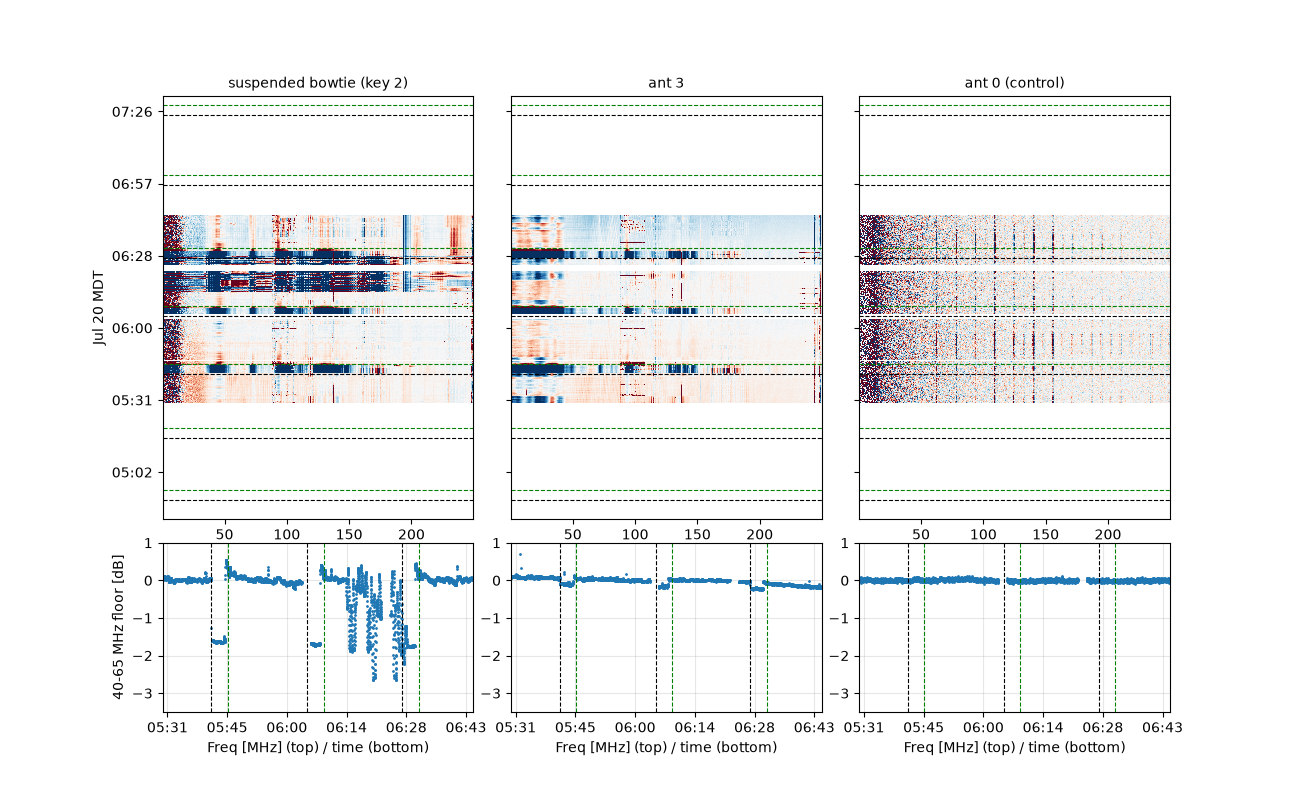

In [6]:
drops = [t0 + 4 for t0, _ in ARP_DROPOUTS if W0 < t0 < W1]
zoom = (times_w >= datetime(2025, 7, 20, 5, 30, tzinfo=MTN).timestamp()) & \
       (times_w <= datetime(2025, 7, 20, 6, 45, tzinfo=MTN).timestamp())
tz_ = times_w[zoom]
dz = dnum(tz_)

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1.2], hspace=0.08, wspace=0.12)
band_ql = nontx & (freq >= 40) & (freq <= 65)
for col, (k, name) in enumerate([("2", "suspended bowtie (key 2)"), ("3", "ant 3"), ("0", "ant 0 (control)")]):
    d = data_w[k][zoom].astype(float)
    d[~ant_w[zoom]] = np.nan
    med = np.nanmedian(d, axis=0)
    with np.errstate(all="ignore"):
        r = 10 * np.log10(np.abs(d / np.where(med > 0, med, 1)))
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(r[:, nontx], aspect="auto", origin="lower", interpolation="nearest",
              extent=[freq[nontx][0], freq[nontx][-1], dz[0], dz[-1]], vmin=-0.6, vmax=0.6, cmap="RdBu_r")
    ax.set_title(name, fontsize=10)
    for dd in drops:
        for x, c in [(dd, "k"), (dd + 240, "g")]:
            ax.axhline(dnum(x), color=c, lw=0.8, ls="--")
    if col == 0:
        ax.yaxis.set_major_formatter(HHMM)
        ax.set_ylabel("Jul 20 MDT")
    else:
        ax.set_yticklabels([])
    ax2 = fig.add_subplot(gs[1, col])
    ts = np.nanmean(d[:, band_ql], axis=1)
    with np.errstate(all="ignore"):
        ax2.plot(dz, 10 * np.log10(ts / np.nanmedian(ts)), ".", ms=2)
    for dd in drops:
        for x, c in [(dd, "k"), (dd + 240, "g")]:
            ax2.axvline(dnum(x), color=c, lw=0.8, ls="--")
    ax2.set_ylim(-3.5, 1)
    ax2.set_xlim(dz[0], dz[-1])
    ax2.xaxis.set_major_formatter(HHMM)
    ax2.grid(alpha=0.3)
    ax2.set_xlabel("Freq [MHz] (top) / time (bottom)")
    if col == 0:
        ax2.set_ylabel("40-65 MHz floor [dB]")
plt.show()

## What turns off: in/out difference spectrum

Median spectrum inside the dropouts vs a local baseline (same window, outside the events). The dropping component is **broadband, ~30–160 MHz**, with depths of 1–3 dB on the bowtie and ants 3/4 — and **ant 0 sees nothing** (< 0.05 dB). For a far-field transmitter all antennas would see the same fractional change; an order-of-magnitude spread between antennas metres apart puts the source **on site, in the near field** (the same gain-free geometry argument as in `radiated_selfRFI_lines.ipynb`).

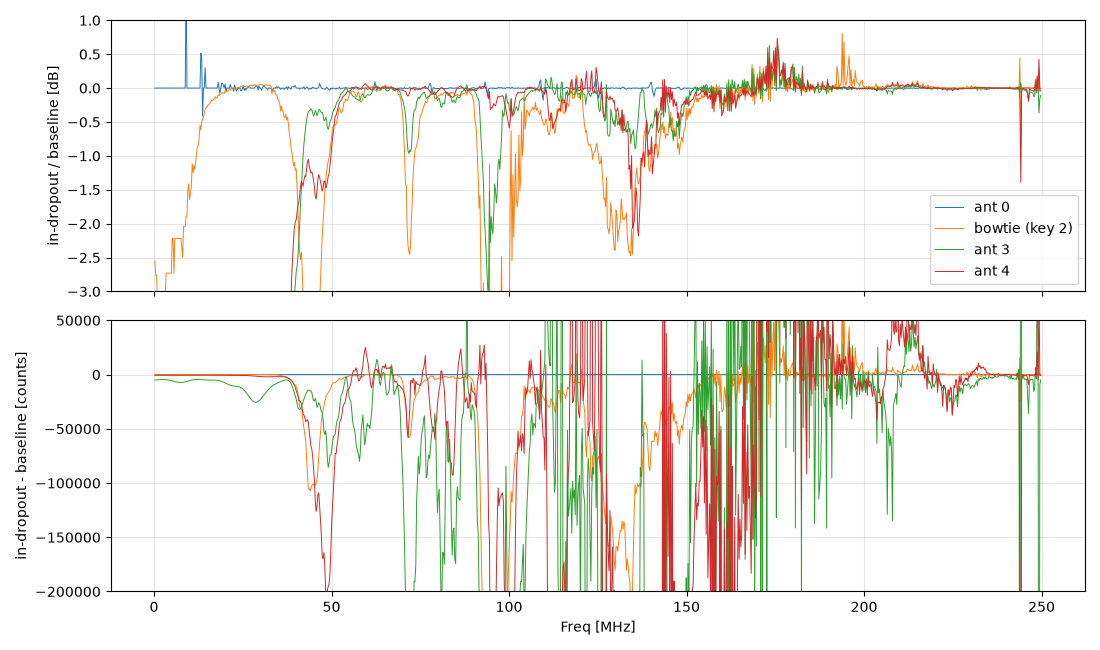

In [7]:
in_drop = np.zeros(len(times_w), bool)
for dd in drops:
    in_drop |= (times_w >= dd + 20) & (times_w <= dd + 220)
out_drop = ~in_drop.copy()
for dd in drops:
    out_drop &= ~((times_w >= dd - 60) & (times_w <= dd + 300))

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
for k in ["0", "2", "3", "4"]:
    d = data_w[k]
    sp_in = np.nanmedian(np.where((ant_w & in_drop)[:, None], d, np.nan), axis=0)
    sp_out = np.nanmedian(np.where((ant_w & out_drop)[:, None], d, np.nan), axis=0)
    with np.errstate(all="ignore"):
        ratio = 10 * np.log10(sp_in / sp_out)
    lbl = "bowtie (key 2)" if k == "2" else f"ant {k}"
    axes[0].plot(freq[nontx], ratio[nontx], lw=0.7, label=lbl)
    axes[1].plot(freq[nontx], (sp_in - sp_out)[nontx], lw=0.7)
axes[0].set_ylabel("in-dropout / baseline [dB]")
axes[0].set_ylim(-3, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].set_ylabel("in-dropout - baseline [counts]")
axes[1].set_ylim(-2e5, 0.5e5)
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Freq [MHz]")
plt.tight_layout()
plt.show()

### Comb stability and the narrowband lines

The received calibration comb is constant through the dropouts to ±0.1 dB on every antenna → the comb transmit chain is not the dropping radiator, and receiver gain is stable (which also rules out any receiver/attenuator state change masquerading as a power drop). The narrowband self-RFI lines are tested **per event** (the lines wander slowly, so a single in/out median is biased): neither the 152.59 MHz line (channel 625) nor the 244.14 MHz line (channels 999/1000) changes consistently across events → the duty-cycled device radiates the broadband floor specifically; the line radiators stay on (the rotation test below pins the 244 MHz line to the platform independently).

In [8]:
comb = np.arange(16, nchan, 16)
print(f"{'ant':>14} {'comb 30-80':>11} {'comb 80-150':>12} {'comb 150-240':>13} "
      f"{'ch625/event':>12} {'ch999+1000/event':>17}")
for k in ["0", "2", "3", "4"]:
    d = data_w[k].astype(float)
    d[(d < 0) | (d > 1.5e9)] = np.nan  # int32-wrap pixels
    d[~ant_w] = np.nan
    sp_in = np.nanmedian(np.where(in_drop[:, None], d, np.nan), axis=0)
    sp_out = np.nanmedian(np.where(out_drop[:, None], d, np.nan), axis=0)
    with np.errstate(all="ignore"):
        r = 10 * np.log10(sp_in / sp_out)
    row = [np.nanmedian(r[comb[(freq[comb] >= f0) & (freq[comb] < f1)]]) for f0, f1 in
           [(30, 80), (80, 150), (150, 240)]]
    # per-event line changes: median over events of in/near-baseline ratio
    deltas = {}
    for name, chs in [("625", [625]), ("244", [999, 1000])]:
        line = np.nansum(d[:, chs], axis=1)
        line[line <= 0] = np.nan
        dl = []
        for dd in drops:
            m_in = (times_w >= dd + 20) & (times_w <= dd + 220)
            m_out = ((times_w >= dd - 300) & (times_w <= dd - 60)) | \
                    ((times_w >= dd + 300) & (times_w <= dd + 540))
            with np.errstate(all="ignore"):
                dl.append(10 * np.log10(np.nanmedian(line[m_in]) / np.nanmedian(line[m_out])))
        deltas[name] = np.nanmedian(dl)
    lbl = "bowtie (key 2)" if k == "2" else f"ant {k}"
    print(f"{lbl:>14} {row[0]:>+10.3f} {row[1]:>+11.3f} {row[2]:>+12.3f} "
          f"{deltas['625']:>+11.2f} {deltas['244']:>+16.2f}")

           ant  comb 30-80  comb 80-150  comb 150-240  ch625/event  ch999+1000/event


         ant 0     +0.000      -0.009       -0.001       +0.00            -0.00


bowtie (key 2)     -0.015      -0.051       +0.033       -0.12            -0.01


         ant 3     -0.080      -0.057       +0.064       +0.03            -0.00


         ant 4     -0.025      -0.002       +0.037       -0.07            -0.16


## Was anything moving during the dropouts?

Direct test of the "rotation event" reading of the hypothesis. The IMU streams report at ~1 Hz with fresh timestamps throughout; their *values* only change during the daytime/evening work and beam-mapping sessions. Every one of arp's 19 events (all overnight/early morning) falls in a period where both IMUs are frozen and the motor server silent: **the rig was stationary during every dropout**. So the dropouts are not caused by rotation — they are the duty cycle of something that is always on site.

In [9]:
def activity_periods(t, v, gap=600):
    chg = np.nonzero(np.any(np.diff(v, axis=0) != 0, axis=1))[0] + 1
    if len(chg) == 0:
        return []
    ct = t[chg]
    breaks = np.nonzero(np.diff(ct) > gap)[0]
    starts = np.concatenate([[0], breaks + 1])
    ends = np.concatenate([breaks, [len(ct) - 1]])
    return [(ct[s], ct[e], e - s + 1) for s, e in zip(starts, ends)]

for name, (t_, v_) in {"imu_panda": (pan_t, pan_q), "imu_antenna": (ant_t, ant_q)}.items():
    print(f"{name} value-change periods:")
    for s, e, n in activity_periods(t_, v_):
        print(f"   {loc(s, '%a %m-%d %H:%M')} - {loc(e, '%H:%M')}  ({n} changes)")

nmoving = 0
for t0, t1 in ARP_DROPOUTS:
    m = (pan_t >= t0 - 60) & (pan_t <= t1 + 60)
    nmoving += np.any(np.diff(pan_q[m], axis=0) != 0)
print(f"\narp events with any imu_panda value change within +-60 s: {nmoving}/{len(ARP_DROPOUTS)}")

imu_panda value-change periods:
   Thu 07-17 16:40 - 17:32  (2904 changes)
   Thu 07-17 19:42 - 22:27  (9154 changes)
   Fri 07-18 09:45 - 09:49  (22 changes)
   Fri 07-18 13:03 - 13:24  (996 changes)
   Sat 07-19 11:09 - 13:20  (7021 changes)
imu_antenna value-change periods:
   Thu 07-17 16:40 - 16:44  (231 changes)
   Thu 07-17 19:42 - 19:47  (287 changes)

arp events with any imu_panda value change within +-60 s: 0/19


## Full-deployment census

Detector: band-mean over the deepest dip bands (95–110 and 125–150 MHz, non-comb channels) on the **bowtie** (key 4 → key 2 across the input swap), detrended by a 35-min running median on antenna-state samples, threshold −0.7 dB, runs merged across < 2-min gaps, duration 2–10 min. Caveats: the comb transmitter's power cycling modulates the same band at the ±0.3 dB level (hence the conservative threshold), and during work hours / rotation sessions the floor moves for other reasons, so daytime counts are upper limits. The detector recovers 15/19 of arp's by-eye events (the misses sit at threshold or are interrupted by cal-cycle masking) and finds the phenomenon running **day and night for the entire deployment**.

In [10]:
CACHE_A = "cache_dropout_passA.npz"
try:
    _z = np.load(CACHE_A)
    times_c, bow2, bow4 = _z["times_c"], _z["bow2"], _z["bow4"]
    print("loaded", CACHE_A)
except FileNotFoundError:
    dip = nontx & (((freq >= 95) & (freq <= 110)) | ((freq >= 125) & (freq <= 150)))
    T, B2, B4 = [], [], []
    nbad = 0
    for fn in sorted(glob.glob(f"{DATA_DIR}/corr_*.h5")):
        try:
            with h5py.File(fn, "r") as f:
                if "header" not in f or "times" not in f["header"]:
                    nbad += 1
                    continue
                t = np.array(json.loads(f["header/times"][()]))
                b2 = f["data/2"][()].astype(np.float32)[:, dip].mean(axis=1)
                b4 = f["data/4"][()].astype(np.float32)[:, dip].mean(axis=1)
            T.append(t), B2.append(b2), B4.append(b4)
        except OSError:
            nbad += 1
    times_c = np.concatenate(T)
    order = np.argsort(times_c)
    times_c, bow2, bow4 = times_c[order], np.concatenate(B2)[order], np.concatenate(B4)[order]
    ok = times_c > 1.7e9  # a handful of integrations carry zeroed timestamps
    times_c, bow2, bow4 = times_c[ok], bow2[ok], bow4[ok]
    np.savez(CACHE_A, times_c=times_c, bow2=bow2, bow4=bow4)
    print(f"scanned ({nbad} unreadable/incomplete files skipped), wrote {CACHE_A}")

ant_c = antenna_mask(times_c, sw_t, sw_s)
bow = np.where(times_c < SWAP, bow4, bow2).astype(float)
bow[~ant_c] = np.nan
good = np.isfinite(bow)
fi = np.interp(times_c, times_c[good], bow[good])
base = median_filter(fi, size=int(35 * 60 / 1.07), mode="nearest")
with np.errstate(all="ignore"):
    r_det = 10 * np.log10(fi / base)
r_det[~good] = np.nan

low = np.nan_to_num(r_det) < -0.7
dd_ = np.diff(low.astype(int))
starts, ends = np.nonzero(dd_ == 1)[0] + 1, np.nonzero(dd_ == -1)[0] + 1
runs = []
for s, e in zip(starts, ends):
    if runs and times_c[s] - times_c[runs[-1][1]] < 120:
        runs[-1][1] = e
    else:
        runs.append([s, e])
# depth = median of the below-threshold samples (the merged span includes masked gaps)
events = np.array([(times_c[s], times_c[e] - times_c[s],
                    np.nanmedian(np.where(r_det[s:e] < -0.7, r_det[s:e], np.nan)))
                   for s, e in runs if 120 < times_c[e] - times_c[s] < 600])

hours = np.array([datetime.fromtimestamp(t, tz=MTN).hour + datetime.fromtimestamp(t, tz=MTN).minute / 60
                  for t in events[:, 0]])
is_night = (hours >= 20.5) | (hours <= 9.5)
matched = sum(bool(np.any(np.abs(events[:, 0] - t0) < 150)) for t0, _ in ARP_DROPOUTS)
gaps = np.diff(events[:, 0]) / 60
from collections import Counter
per_day = Counter(loc(t, "%a %m-%d") for t in events[:, 0])
print(f"{len(events)} events; per day: {dict(sorted(per_day.items(), key=lambda kv: kv[0][4:]))}")
print(f"{is_night.sum()} at night (20:30-09:30 MDT), {(~is_night).sum()} in work hours (daytime = upper limit)")
print(f"duration: median {np.median(events[:, 1]):.0f} s, 10-90%: "
      f"[{np.percentile(events[:, 1], 10):.0f}, {np.percentile(events[:, 1], 90):.0f}] s")
print(f"depth (dip band, below-threshold samples): median {np.nanmedian(events[:, 2]):.2f} dB")
print(f"gaps between events: median {np.median(gaps[gaps < 120]):.0f} min (of gaps < 2 h)")
print(f"arp events recovered: {matched}/{len(ARP_DROPOUTS)}")
# duty cycle over valid antenna-state samples only (data exist from Jul 15, telemetry from Jul 17)
in_ev = np.zeros(len(times_c), bool)
for t0, dur, _ in events:
    in_ev |= (times_c >= t0) & (times_c <= t0 + dur)
hrs_c = np.array([datetime.fromtimestamp(t, tz=MTN).hour + datetime.fromtimestamp(t, tz=MTN).minute / 60
                  for t in times_c])
night_c = (hrs_c >= 20.5) | (hrs_c <= 9.5)
print(f"fraction of antenna-state time in dropout (floor OFF): {in_ev[good].mean() * 100:.1f}% overall, "
      f"{in_ev[good & night_c].mean() * 100:.1f}% in night hours "
      f"-> the floor is PRESENT ~{100 - in_ev[good & night_c].mean() * 100:.0f}% of the time")

loaded cache_dropout_passA.npz
91 events; per day: {'Thu 07-17': 11, 'Fri 07-18': 28, 'Sat 07-19': 23, 'Sun 07-20': 29}
38 at night (20:30-09:30 MDT), 53 in work hours (daytime = upper limit)
duration: median 233 s, 10-90%: [140, 512] s
depth (dip band, below-threshold samples): median -1.12 dB
gaps between events: median 24 min (of gaps < 2 h)
arp events recovered: 15/19


fraction of antenna-state time in dropout (floor OFF): 12.1% overall, 10.7% in night hours -> the floor is PRESENT ~89% of the time


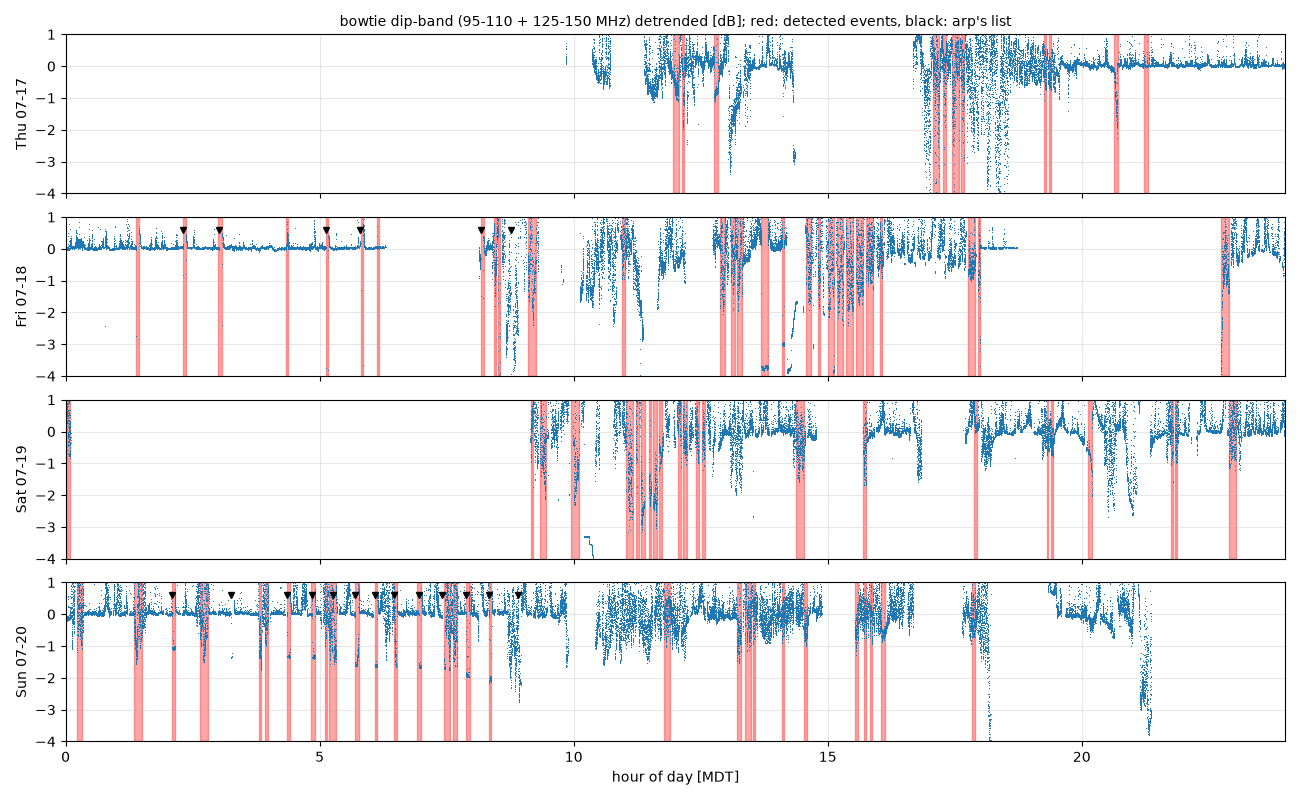

In [11]:
days = [datetime(2025, 7, d, 0, 0, tzinfo=MTN) for d in range(17, 21)]
fig, axes = plt.subplots(len(days), 1, figsize=(13, 8), sharex=True, sharey=True)
for ax, day in zip(axes, days):
    d0 = day.timestamp()
    m = (times_c >= d0) & (times_c < d0 + 86400)
    ax.plot((times_c[m] - d0) / 3600, r_det[m], ",", color="C0")
    for t0, dur, _ in events:
        if d0 <= t0 < d0 + 86400:
            ax.axvspan((t0 - d0) / 3600, (t0 + dur - d0) / 3600, color="r", alpha=0.35)
    for t0, _ in ARP_DROPOUTS:
        if d0 <= t0 < d0 + 86400:
            ax.plot((t0 - d0) / 3600, 0.6, "kv", ms=5)
    ax.set_ylabel(day.strftime("%a %m-%d"))
    ax.set_ylim(-4, 1)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("hour of day [MDT]")
axes[-1].set_xlim(0, 24)
axes[0].set_title("bowtie dip-band (95-110 + 125-150 MHz) detrended [dB]; red: detected events, "
                  "black: arp's list", fontsize=10)
plt.tight_layout()
plt.show()

## The level: stacked off-window spectrum

Stacking the night events (clean of human activity) gives the in-situ spectrum of the duty-cycled radiator on each antenna, expressed as the **fraction of total measured power it contributes**. Each event is differenced against its own ±9-min local baseline, so sky drift and FM fading cannot masquerade as floor power (a pooled in/out stack fails exactly that way). This is the number the reviewer is asking for: on the bowtie the floor is typically ~7–11% of total power across 40–150 MHz, peaking at ~40% (40–65 MHz) and ~25% (110–150 MHz) at specific frequencies, while ant 0 stays at the ~0.1% level. Note this is the floor of *one* device — the one that pauses; the always-on lines (e.g. 152.59, 244.14 MHz) are characterized in `radiated_selfRFI_lines.ipynb`.

loaded cache_dropout_passB.npz


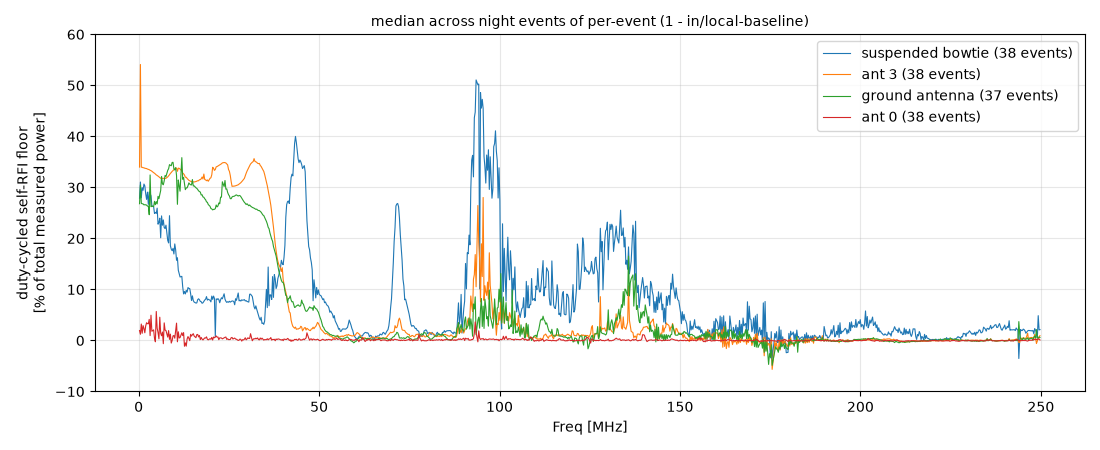

 bowtie 40-65 MHz: median   6.8%, peak  40.0% of total power
      3 40-65 MHz: median   1.4%, peak  11.9% of total power
      0 40-65 MHz: median   0.1%, peak   1.5% of total power
 bowtie 110-150 MHz: median  10.8%, peak  25.5% of total power
      3 110-150 MHz: median   1.4%, peak  10.7% of total power
      0 110-150 MHz: median   0.0%, peak   1.1% of total power


In [12]:
CACHE_B = "cache_dropout_passB.npz"
nev = events[is_night]
ev_t0, ev_t1 = nev[:, 0], nev[:, 0] + nev[:, 1]
all_t0, all_t1 = events[:, 0], events[:, 0] + events[:, 1]
PHYS = ["bowtie", "ground", "0", "3"]
nE = len(nev)
try:
    _z = np.load(CACHE_B)
    S_IN = {p: _z[f"sin_{p}"] for p in PHYS}
    S_OUT = {p: _z[f"sout_{p}"] for p in PHYS}
    C_IN = {p: _z[f"cin_{p}"] for p in PHYS}
    C_OUT = {p: _z[f"cout_{p}"] for p in PHYS}
    print("loaded", CACHE_B)
except FileNotFoundError:
    # per-event paired accumulation: each event gets its own local (+-9 min) baseline,
    # so sky drift and FM fading between epochs cannot masquerade as floor power
    S_IN = {p: np.zeros((nE, nchan)) for p in PHYS}
    S_OUT = {p: np.zeros((nE, nchan)) for p in PHYS}
    C_IN = {p: np.zeros((nE, nchan)) for p in PHYS}
    C_OUT = {p: np.zeros((nE, nchan)) for p in PHYS}
    for fn in sorted(glob.glob(f"{DATA_DIR}/corr_*.h5")):
        try:
            with h5py.File(fn, "r") as f:
                if "header" not in f or "times" not in f["header"]:
                    continue
                t = np.array(json.loads(f["header/times"][()]))
                if not np.any((t[-1] > ev_t0 - 600) & (t[0] < ev_t1 + 600)):
                    continue
                a = antenna_mask(t, sw_t, sw_s)
                near = np.zeros(len(t), bool)  # near ANY event (baseline exclusion)
                for t0, t1 in zip(all_t0, all_t1):
                    near |= (t >= t0 - 60) & (t <= t1 + 60)
                key_map = {"bowtie": "4", "ground": "2"} if t[0] < SWAP else {"bowtie": "2", "ground": "4"}
                key_map.update({"0": "0", "3": "3"})
                data_f = {}
                for ie in range(nE):
                    t0, t1 = ev_t0[ie], ev_t1[ie]
                    m_in = a & (t >= t0 + 20) & (t <= t1 - 20)
                    m_out = a & ~near & (((t >= t0 - 540) & (t < t0)) | ((t > t1) & (t <= t1 + 540)))
                    if not (m_in.any() or m_out.any()):
                        continue
                    for p, k in key_map.items():
                        if p not in data_f:
                            d = f[f"data/{k}"][()].astype(np.float64)
                            valid = (d >= 0) & (d < 1.5e9)  # int32-wrap pixels
                            data_f[p] = (np.where(valid, d, 0), valid)
                        d, valid = data_f[p]
                        S_IN[p][ie] += d[m_in].sum(axis=0)
                        C_IN[p][ie] += valid[m_in].sum(axis=0)
                        S_OUT[p][ie] += d[m_out].sum(axis=0)
                        C_OUT[p][ie] += valid[m_out].sum(axis=0)
        except OSError:
            continue
    np.savez(CACHE_B, **{f"sin_{p}": S_IN[p] for p in PHYS}, **{f"sout_{p}": S_OUT[p] for p in PHYS},
             **{f"cin_{p}": C_IN[p] for p in PHYS}, **{f"cout_{p}": C_OUT[p] for p in PHYS})
    print(f"accumulated {nE} night events, wrote {CACHE_B}")

# per-event fraction, then median across events with enough samples on both sides
FRAC = {}
for p in PHYS:
    with np.errstate(all="ignore"):
        fr = 1 - (S_IN[p] / C_IN[p]) / (S_OUT[p] / C_OUT[p])
    ok_ev = (C_IN[p].min(axis=1) >= 50) & (C_OUT[p].min(axis=1) >= 100)
    FRAC[p] = (np.nanmedian(fr[ok_ev], axis=0), ok_ev.sum())

fig, ax = plt.subplots(figsize=(11, 4.5))
for p, lbl in [("bowtie", "suspended bowtie"), ("3", "ant 3"), ("ground", "ground antenna"), ("0", "ant 0")]:
    frac, nok = FRAC[p]
    ax.plot(freq[nontx], 100 * frac[nontx], lw=0.8, label=f"{lbl} ({nok} events)")
ax.set_xlabel("Freq [MHz]")
ax.set_ylabel("duty-cycled self-RFI floor\n[% of total measured power]")
ax.set_ylim(-10, 60)
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("median across night events of per-event (1 - in/local-baseline)", fontsize=10)
plt.tight_layout()
plt.show()
for f0, f1 in [(40, 65), (110, 150)]:
    b = nontx & (freq >= f0) & (freq <= f1)
    for p in ["bowtie", "3", "0"]:
        frac, _ = FRAC[p]
        print(f"{p:>7} {f0}-{f1} MHz: median {100 * np.nanmedian(frac[b]):5.1f}%, "
              f"peak {100 * np.nanmax(frac[b]):5.1f}% of total power")

## Rotation dependence (Jul 19, 13:05–13:20 raster)

The clean automated pitch raster at the end of the Sat beam-mapping session: the platform sweeps pitch ±90° ten times while the **suspended bowtie hangs stationary**. The bowtie's broadband floor modulates by up to ~1.5 dB *synchronously with the sweeps* (roughly symmetric in pitch, as a radiation/shadowing pattern should be — the binned curve underestimates the swing because the modulation is not a function of pitch alone), and its 244 MHz line drops ~3 dB and oscillates, snapping back to a steady level the moment the platform parks (13:19). A far-field external transmitter cannot know our platform orientation: **both the floor and the 244 MHz line are radiated from the rotating structure itself**. This is the rotation dependence arp saw, made explicit. Note the two diagnostics separate cleanly: the floor switches off in the dropouts but the line does not, while both modulate with rotation — consistent with two radiators (or two stages of one device) in the same enclosure.

In [13]:
R0 = datetime(2025, 7, 19, 12, 55, tzinfo=MTN).timestamp()
R1 = datetime(2025, 7, 19, 13, 25, tzinfo=MTN).timestamp()
T, D = [], {k: [] for k in ["2", "3"]}
for fn in sorted(glob.glob(f"{DATA_DIR}/corr_20250719_*.h5")):
    try:
        with h5py.File(fn, "r") as f:
            t = np.array(json.loads(f["header/times"][()]))
            if t[0] > R1 or t[-1] < R0:
                continue
            T.append(t)
            for k in D:
                D[k].append(f[f"data/{k}"][()].astype(np.float32))
    except OSError:
        continue
times_r = np.concatenate(T)
order = np.argsort(times_r)
times_r = times_r[order]
data_r = {k: np.concatenate(v)[order] for k, v in D.items()}
m = (times_r >= R0) & (times_r <= R1)
times_r = times_r[m]
data_r = {k: v[m] for k, v in data_r.items()}
ant_r = antenna_mask(times_r, sw_t, sw_s)
mi = (pan_t >= R0) & (pan_t <= R1)
yaw_r, pitch_r, roll_r = quat_to_euler(pan_q[mi])
pitch_i = np.interp(times_r, pan_t[mi], pitch_r)  # platform pitch at each integration
print(f"{len(times_r)} integrations, {mi.sum()} imu reports")

1673 integrations, 1670 imu reports


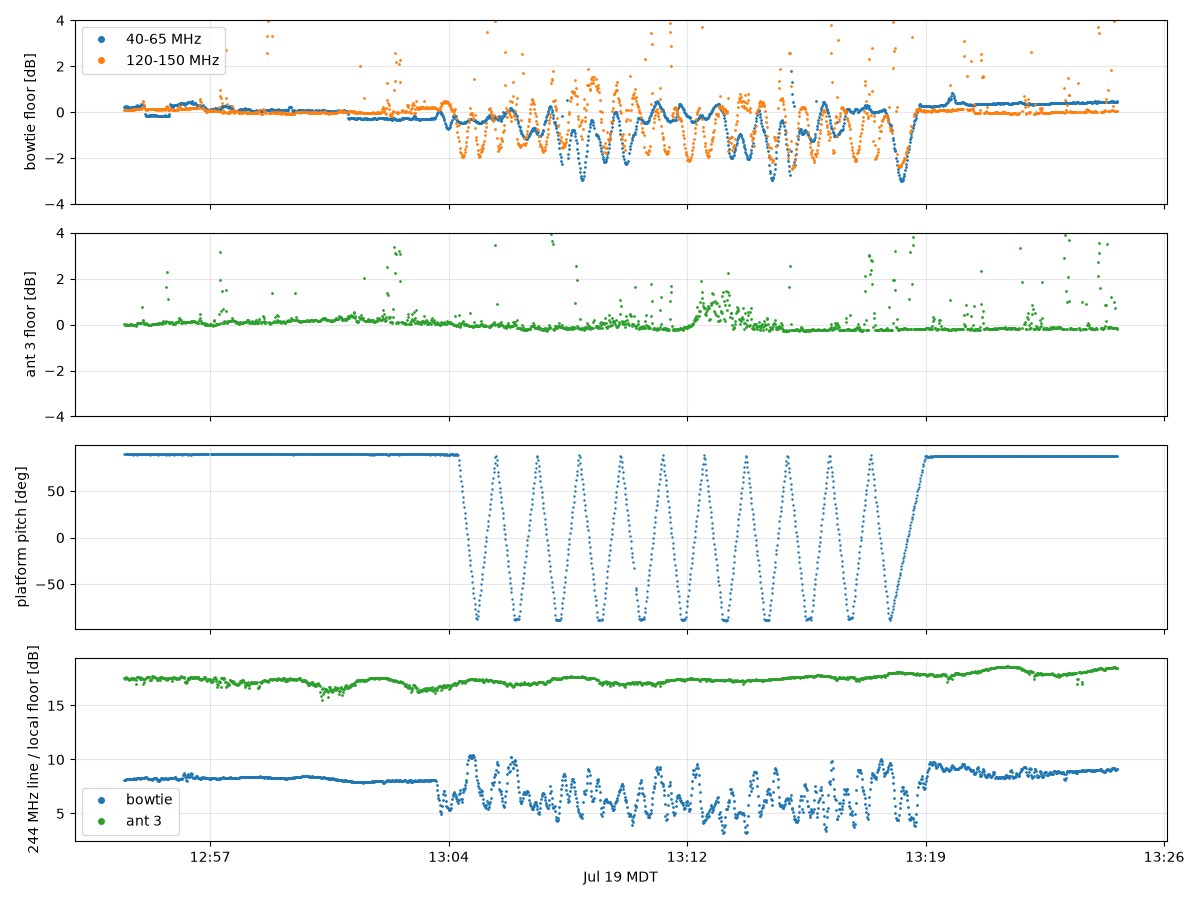

In [14]:
band1 = nontx & (freq >= 40) & (freq <= 65)
band2 = nontx & (freq >= 120) & (freq <= 150)
dr = dnum(times_r)
idr = dnum(pan_t[mi])

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
d2 = data_r["2"].astype(float)
d2[~ant_r] = np.nan
for bb, lbl in [(band1, "40-65 MHz"), (band2, "120-150 MHz")]:
    ts = np.nanmean(d2[:, bb], axis=1)
    with np.errstate(all="ignore"):
        axes[0].plot(dr, 10 * np.log10(ts / np.nanmedian(ts)), ".", ms=2, label=lbl)
axes[0].set_ylabel("bowtie floor [dB]")
axes[0].set_ylim(-4, 4)
axes[0].legend(markerscale=4)
axes[0].grid(alpha=0.3)
d3 = data_r["3"].astype(float)
d3[~ant_r] = np.nan
ts3 = np.nanmean(d3[:, band2], axis=1)
with np.errstate(all="ignore"):
    axes[1].plot(dr, 10 * np.log10(ts3 / np.nanmedian(ts3)), ".", ms=2, color="C2")
axes[1].set_ylabel("ant 3 floor [dB]")
axes[1].set_ylim(-4, 4)
axes[1].grid(alpha=0.3)
axes[2].plot(idr, pitch_r, ".", ms=1.5)
axes[2].set_ylabel("platform pitch [deg]")
axes[2].grid(alpha=0.3)
for k, c in [("2", "C0"), ("3", "C2")]:
    d = data_r[k].astype(float)
    d[~ant_r] = np.nan
    line = np.nansum(d[:, 999:1001], axis=1)
    ref = np.nanmedian(d[:, [995, 996, 997, 1002, 1003]], axis=1)
    with np.errstate(all="ignore"):
        axes[3].plot(dr, 10 * np.log10(line / ref), ".", ms=2, color=c,
                     label="bowtie" if k == "2" else f"ant {k}")
axes[3].set_ylabel("244 MHz line / local floor [dB]")
axes[3].legend(markerscale=4)
axes[3].grid(alpha=0.3)
axes[3].xaxis.set_major_formatter(HHMM)
axes[3].set_xlabel("Jul 19 MDT")
plt.tight_layout()
plt.show()

bowtie 40-65 MHz: peak-to-peak modulation with pitch 0.6 dB
bowtie 120-150 MHz: peak-to-peak modulation with pitch 1.1 dB


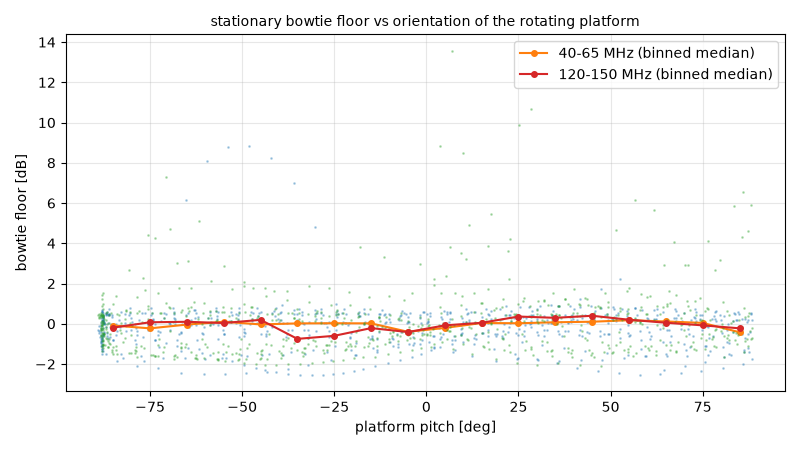

In [15]:
# binned floor vs platform pitch, raster interval only
ras = (times_r >= datetime(2025, 7, 19, 13, 5, 30, tzinfo=MTN).timestamp()) & \
      (times_r <= datetime(2025, 7, 19, 13, 19, 0, tzinfo=MTN).timestamp()) & ant_r
fig, ax = plt.subplots(figsize=(8, 4.5))
edges = np.arange(-90, 95, 10)
ctr = 0.5 * (edges[:-1] + edges[1:])
for bb, lbl in [(band1, "40-65 MHz"), (band2, "120-150 MHz")]:
    ts = np.nanmean(np.where(ant_r[:, None], data_r["2"], np.nan)[:, bb], axis=1)
    with np.errstate(all="ignore"):
        y = 10 * np.log10(ts / np.nanmedian(ts[ras]))
    ax.plot(pitch_i[ras], y[ras], ".", ms=2, alpha=0.3)
    med = [np.nanmedian(y[ras & (pitch_i >= e0) & (pitch_i < e1)]) for e0, e1 in zip(edges[:-1], edges[1:])]
    ax.plot(ctr, med, "-o", ms=4, label=f"{lbl} (binned median)")
    print(f"bowtie {lbl}: peak-to-peak modulation with pitch {np.nanmax(med) - np.nanmin(med):.1f} dB")
ax.set_xlabel("platform pitch [deg]")
ax.set_ylabel("bowtie floor [dB]")
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("stationary bowtie floor vs orientation of the rotating platform", fontsize=10)
plt.tight_layout()
plt.show()

## Conclusions

**For the reviewer response.** The "noise dropouts" are the off-windows of a single duty-cycled, on-site, broadband radiator — and they turn out to be a gift: they provide an in-situ, antenna-referenced measurement of the self-RFI floor without any extra hardware.

1. **Current level.** The duty-cycled floor spans ~30–160 MHz and contributes typically ~7–11% of the total measured power on the suspended bowtie across 40–150 MHz, peaking at ~40% at specific frequencies (individual deep events reach 2–3 dB, i.e. ~40–50% of total power); it is present ~89% of the time (~20 off-windows/day, ~4 min each). The antenna-to-antenna variation of the fractional level (ant 0: ~0.1%) is the gain-free signature of a near-field source. The narrowband self-RFI lines are characterized separately in `radiated_selfRFI_lines.ipynb`; they do not switch with the floor (separate radiators or stages), but the 244.14 MHz line is pinned to the platform by the rotation test.
2. **Source localization.** Rotating the platform modulates the floor and the 244 MHz line received by the *stationary* bowtie (up to ~1.5 dB and ~3 dB respectively), and the modulation stops the moment the platform parks: the radiators are on the rotating structure (receiver/electronics enclosure), not external. The comb's constancy through the dropouts exonerates the transmit chain; the telemetry exonerates the motors (idle overnight), the temperature controller (idle all deployment), and the VNA/RF-switch schedule (cadence mismatch).
3. **Refinement of arp's hypothesis.** Rotation does not *cause* the dropouts — the rig is stationary during every one. Rotation dependence is a steady-state property of the emission, and the dropouts are the floor radiator's own ~25–70-min duty cycle with a tightly software-like ~240-s off-time.
4. **Mitigation strategy.** (a) The ~240-s off-windows are clean references interleaved through all data — usable for excision and for transferring the measured floor spectrum out of science integrations. (b) The duty-cycle signature (exact ~4-min off-time, 25–70-min quasi-period, day and night) plus on-platform localization narrows the candidate list to the continuously powered platform electronics (compute/network/power subsystems — not motors, not thermal control); a per-subsystem power-cycling audit at the next deployment, watched live in this dip-band statistic, would identify it in minutes. (c) Shielding/filtering of the platform enclosure then addresses the floor and the lines together.

**Caveats.** Daytime event counts are upper limits (work activity crosses the detector threshold); the census detector misses 4/19 of arp's by-eye events (threshold/cal-cycle interruptions), so per-event statistics, not the event list, are the robust product. The exact identity of the duty-cycled device cannot be determined from this dataset alone.